### Imports

In [135]:
import glob
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
from tensorflow.keras import layers, models
from tensorflow.keras.losses import MeanSquaredError

sys.path.insert(0, "../../")
from config import DATASETS_PATH, IMG_SHAPE, SEED

### Tensorflow config

In [136]:
gpus = tf.config.list_physical_devices("GPU")
print("GPU Available:", gpus)
print("cuDNN Enabled:", tf.test.is_built_with_cuda())

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Set the number of intra-op and inter-op threads
NUM_CORES = 12
# tf.config.threading.set_intra_op_parallelism_threads(NUM_CORES)
# tf.config.threading.set_inter_op_parallelism_threads(NUM_CORES)

# Set for reproducibility
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
cuDNN Enabled: True


### Dataset preparation

In [137]:
IMAGES_UNLABELED_PATH = os.path.join(DATASETS_PATH, "cropped", "vae", "train", "untagged")
IMAGES_LABELED_PATH = os.path.join(DATASETS_PATH, "cropped", "vae", "train", "tagged")
IMAGES_TEST_PATH = os.path.join(DATASETS_PATH, "cropped", "vae", "test")
BATCH_SIZE = 64


def load_and_preprocess_image(path):
    """Loads and preprocesses a single image, ignoring labels."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, IMG_SHAPE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, image


def make_unlabeled_dataset(file_list, batch_size):
    """Creates a tf.data.Dataset for unlabeled images."""
    ds = tf.data.Dataset.from_tensor_slices(file_list)
    ds = ds.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

In [138]:
# Get all unlabeled image paths
unlabeled_files = glob.glob(os.path.join(IMAGES_UNLABELED_PATH, "*"))

# Get all labeled image paths (from all subdirectories)
labeled_files = glob.glob(os.path.join(IMAGES_LABELED_PATH, "*/*"))

# --- THIS IS THE KEY STEP ---
# Combine them into a single list for M1 training
all_files = unlabeled_files + labeled_files
print(f"Total images for M1 training: {len(all_files)}")

# Split the combined list for training and validation
m1_train_files, m1_val_files = train_test_split(all_files, test_size=0.2, random_state=42)
print(f"M1 training set size: {len(m1_train_files)}")
print(f"M1 validation set size: {len(m1_val_files)}")

Total images for M1 training: 8443
M1 training set size: 6754
M1 validation set size: 1689


### Definition of the encoder

In [139]:
# A custom layer to sample from the latent space
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [140]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.layers import BatchNormalization, LeakyReLU


def build_encoder(latent_dim):
    """Builds a deeper encoder for 200x200 images."""
    inputs = layers.Input(shape=(200, 200, 1))

    # Downsampling from 200x200 -> 100x100
    x = layers.Conv2D(32, 3, strides=2, padding="same")(inputs)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 100x100 -> 50x50
    x = layers.Conv2D(64, 3, strides=2, padding="same")(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 50x50 -> 25x25
    x = layers.Conv2D(128, 3, strides=2, padding="same")(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 25x25 -> 13x13 (approx)
    x = layers.Conv2D(256, 3, strides=2, padding="same")(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 13x13 -> 7x7
    # x = layers.Conv2D(256, 3, strides=1, padding='same')(x)
    # x = LeakyReLU(negative_slope=0.2)(x)
    # x = BatchNormalization()(x)

    # We'll stop downsampling here at a 13x13 feature map
    # Note: 200 -> 100 -> 50 -> 25 -> 13 (due to 'same' padding)

    # Fully Connected Head
    x = layers.Flatten()(x)
    x = layers.Dense(256)(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    x = layers.Dropout(0.2)(x)  # Rate of 0.5 is a common starting point

    # Latent space
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])  # Assumes Sampling layer is defined

    encoder = models.Model(inputs, [z_mean, z_log_var, z], name="encoder")
    return encoder

### Definition of decoder

In [141]:
def build_decoder(latent_dim):
    """Builds a deeper decoder for 200x200 images."""
    latent_inputs = layers.Input(shape=(latent_dim,))

    # Prepare for upsampling
    x = layers.Dense(256)(latent_inputs)
    x = LeakyReLU(negative_slope=0.2)(x)
    # The shape corresponds to the encoder's output before flattening
    x = layers.Dense(13 * 13 * 256)(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = layers.Reshape((13, 13, 256))(x)

    # Upsampling from 7x7 -> 14x14
    # x = layers.Conv2DTranspose(512, 3, strides=2, padding='same')(x)
    # x = LeakyReLU(negative_slope=0.2)(x)
    # x = BatchNormalization()(x)

    # Upsampling from 14x14 -> 28x28
    x = layers.Conv2DTranspose(256, 3, strides=2, padding="same")(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # # 28x28 -> 56x56
    x = layers.Conv2DTranspose(128, 3, strides=2, padding="same")(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 56x56 -> 112x112
    x = layers.Conv2DTranspose(64, 3, strides=2, padding="same")(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    # 112x112 -> 224x224
    x = layers.Conv2DTranspose(32, 3, strides=2, padding="same")(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    x = BatchNormalization()(x)

    x = layers.Cropping2D(((4, 4), (4, 4)))(x)

    # Final output layer
    outputs = layers.Conv2DTranspose(1, 5, activation="sigmoid", padding="same")(x)

    decoder = models.Model(latent_inputs, outputs, name="decoder")
    return decoder

### Definition of the VAE

#### Losses

In [142]:
class CustomLoss(tf.keras.losses.Loss):
    def __init__(self, y, z, name="custom_loss"):
        super().__init__(name=name)
        # Weights
        self.y = y
        self.z = z

        # MAE
        self.mae_loss_fn = tf.keras.losses.MeanAbsoluteError()

    # SSIM loss
    def ssim_loss(self, y_true, y_pred):
        ssim = (1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))) / 2
        return ssim

    def call(self, y_true, y_pred):
        mae_loss = self.mae_loss_fn(y_true, y_pred)
        ssim = self.ssim_loss(y_true, y_pred)
        return self.y * mae_loss + self.z * ssim

#### VAE Model

In [143]:
def apply_gamma_correction(image, gamma=0.8):
    """Applies a differentiable gamma correction."""
    # Ensure the image values are not zero to avoid issues with log/pow
    clipped_image = tf.clip_by_value(image, 1e-8, 1.0)
    return tf.pow(clipped_image, gamma)

In [144]:
class VAE(models.Model):
    def __init__(
        self,
        encoder,
        decoder,
        latent_dim,
        reconstruction_loss_fn,
        beta,
        reconstruction_weight=1,
        **kwargs,
    ):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta  # If kl_annealing is used as callback replace with this: tf.Variable(0.0, trainable=False, name='kl_beta_weight')
        self.recon_loss_fn = reconstruction_loss_fn  # MeanSquaredError()
        self.reconstruction_weight = reconstruction_weight

        self.prior_mean = self.add_weight(
            shape=(latent_dim,), initializer="zeros", name="prior_mean", trainable=True
        )
        self.prior_log_var = self.add_weight(
            shape=(latent_dim,), initializer="zeros", name="prior_log_var", trainable=True
        )

    def call(self, inputs):
        """Defines the forward pass of the VAE."""
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return z_mean, z_log_var, reconstruction

    def _calculate_loss(self, data):
        """Helper function to calculate all VAE loss components."""
        if isinstance(data, tuple):
            data = data[0]

        # Generate reconstruction
        z_mean, z_log_var, reconstruction = self(data)
        z_mean, z_log_var, _ = self.encoder(data)

        # Reconstruction loss
        if self.recon_loss_fn is None:
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
        else:
            gamma_value = 0.8  # A value < 1.0 will increase contrast in shadows
            true_enhanced = apply_gamma_correction(data, gamma_value)
            recon_enhanced = apply_gamma_correction(reconstruction, gamma_value)

            true_edges = tf.image.sobel_edges(true_enhanced)
            reconstruction_edges = tf.image.sobel_edges(recon_enhanced)

            reconstruction_loss = self.recon_loss_fn(true_edges, reconstruction_edges)
            reconstruction_loss = tf.reduce_mean(reconstruction_loss) * (
                IMG_SHAPE[0] * IMG_SHAPE[0]
            )

        # Kullback-Leibler Divergence loss
        # kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)) #Convenvional VAE KL Divergence
        kl_loss = 0.5 * (  # new KL divergence with learnable prior
            self.prior_log_var
            - z_log_var
            + (tf.exp(z_log_var) + tf.square(z_mean - self.prior_mean)) / tf.exp(self.prior_log_var)
            - 1.0
        )
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))

        total_loss = reconstruction_loss + self.beta * kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        """Defines the logic for one training step."""
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self._calculate_loss(data)

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights, strict=False))

        # We manually log our losses, so this is all that's needed.
        return {
            "loss": total_loss,  # 'loss' is the primary monitored metric
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
            "beta": self.beta,
        }

    def test_step(self, data):
        # (This method is now much cleaner)
        total_loss, reconstruction_loss, kl_loss = self._calculate_loss(data)
        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss,
        }

### Training

#### Callbacks definition

In [145]:
class LiveImageGenerator(tf.keras.callbacks.Callback):
    def __init__(self, num_images, latent_dim):
        super().__init__()
        self.num_images = num_images
        self.latent_dim = latent_dim

    def on_epoch_end(self, epoch, logs=None):
        # Generate random latent vectors
        random_latent_vectors = tf.random.normal(shape=(self.num_images, self.latent_dim))

        # Use the decoder to generate images
        generated_images = self.model.decoder.predict(random_latent_vectors, verbose=0)

        # Create a plot grid
        grid_size = int(np.sqrt(self.num_images))
        fig, axes = plt.subplots(grid_size, grid_size, figsize=(5, 5))
        fig.suptitle(f"Generated Images at Epoch {epoch + 1}", fontsize=12)

        for i, ax in enumerate(axes.flat):
            # --- THIS IS THE CHANGE ---
            # .squeeze() removes the channel dimension, and cmap='gray' sets the colormap.
            ax.imshow(generated_images[i].squeeze(), cmap="gray")
            ax.axis("off")

        # Clear the previous output and display the new plot
        clear_output(wait=True)
        plt.show()


class KLAnnealingCallback(tf.keras.callbacks.Callback):
    def __init__(self, anneal_duration_steps, kl_end_weight=0.5, kl_start_weight=0.0):
        super().__init__()
        self.anneal_duration = float(anneal_duration_steps)
        self.kl_start = float(kl_start_weight)
        self.kl_end = float(kl_end_weight)
        self.step = 0.0

    def on_train_batch_begin(self, batch, logs=None):
        # This method is called at the start of every training batch
        self.step += 1

        # Calculate the new beta value using a linear schedule
        ratio = min(1.0, self.step / self.anneal_duration)
        new_beta = self.kl_start + (self.kl_end - self.kl_start) * ratio

        # Update the beta value inside the VAE model
        self.model.beta.assign(new_beta)

In [146]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stopping = EarlyStopping(
    monitor="val_loss",  # The metric to monitor
    patience=7,  # Number of epochs to wait for improvement
    verbose=1,  # Print a message when stopping
    restore_best_weights=True,  # Restore weights from the best epoch
)

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",  # The metric to monitor
    factor=0.2,  # Factor by which to reduce the learning rate (new_lr = lr * factor)
    patience=7,  # Number of epochs to wait for improvement
    verbose=1,  # Print a message when the LR is updated
    min_lr=1e-6,  # The minimum learning rate
)

#### VAE training

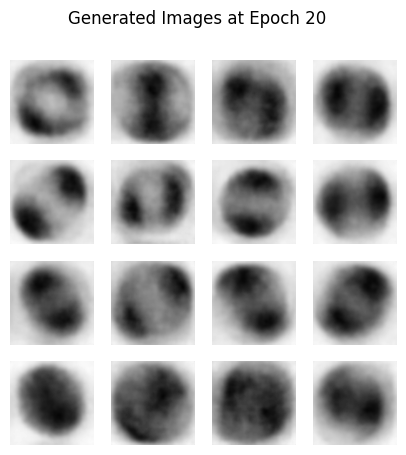

106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - beta: 2.0000 - kl_loss: 2.8264 - loss: 797.4633 - reconstruction_loss: 791.8105 - val_kl_loss: 2.9693 - val_loss: 953.0474 - val_reconstruction_loss: 947.1086 - learning_rate: 2.0000e-05
Training complete!


In [147]:
# --- Definition of hyperparameters ---
LATENT_DIM = 32
EPOCHS = 20
BETA = 2
NUM_SAMPLES_TO_GENERATE = 16  # e.g., for a 4x4 grid

# --- Define datasets ---
m1_train_dataset = make_unlabeled_dataset(m1_train_files, BATCH_SIZE)
m1_val_dataset = make_unlabeled_dataset(m1_val_files, BATCH_SIZE)

# --- Instantiate callbacks ---

live_image_callback = LiveImageGenerator(num_images=NUM_SAMPLES_TO_GENERATE, latent_dim=LATENT_DIM)

steps_per_epoch = len(m1_train_files) // BATCH_SIZE
annealing_duration = 10 * steps_per_epoch
kl_annealing_callback = KLAnnealingCallback(
    kl_end_weight=BETA, anneal_duration_steps=annealing_duration
)

callbacks = [lr_scheduler, live_image_callback]  # early_stopping, kl_annealing_callback]

# --- Instance models classes ---
encoder = build_encoder(LATENT_DIM)
decoder = build_decoder(LATENT_DIM)

# Define loss to use
# custom_recon_loss = CustomLoss(y=0.17, z=0.83)
custom_recon_loss = MeanSquaredError()
# custom_recon_loss = None

vae = VAE(
    encoder, decoder, reconstruction_loss_fn=custom_recon_loss, latent_dim=LATENT_DIM, beta=BETA
)

# --- Compile the model ---
vae.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4))


# --- Train the model ---
print("Training the VAE (M1 model) with beta annealing...")
history = vae.fit(
    m1_train_dataset, epochs=EPOCHS, validation_data=m1_val_dataset, callbacks=callbacks
)

print("Training complete!")

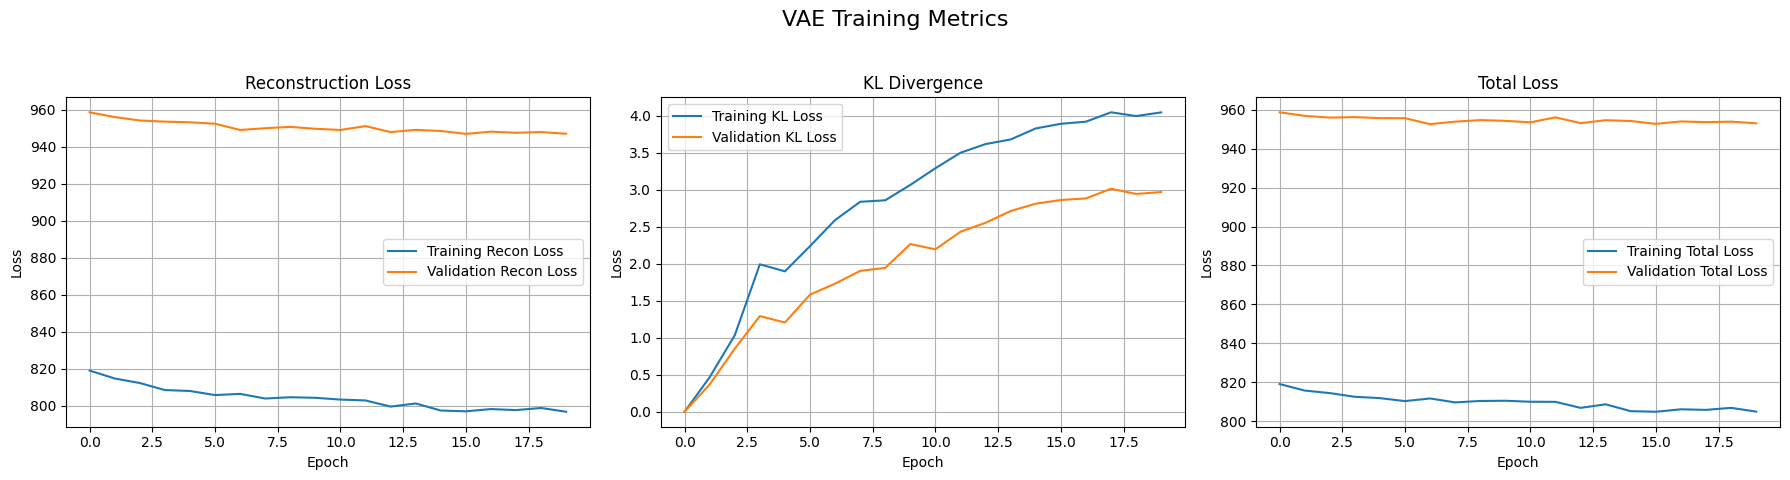

In [148]:
import pandas as pd

# Create a DataFrame from the history object for easier plotting
history_df = pd.DataFrame(history.history)

# Create a figure with three subplots arranged in one row
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("VAE Training Metrics", fontsize=16)

# --- Plot 1: Reconstruction Loss ---
axes[0].plot(history_df["reconstruction_loss"], label="Training Recon Loss")
axes[0].plot(history_df["val_reconstruction_loss"], label="Validation Recon Loss")
axes[0].set_title("Reconstruction Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: KL Loss ---
axes[1].plot(history_df["kl_loss"], label="Training KL Loss")
axes[1].plot(history_df["val_kl_loss"], label="Validation KL Loss")
axes[1].set_title("KL Divergence")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

# --- Plot 3: Total Loss ---
axes[2].plot(history_df["loss"], label="Training Total Loss")
axes[2].plot(history_df["val_loss"], label="Validation Total Loss")
axes[2].set_title("Total Loss")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Loss")
axes[2].legend()
axes[2].grid(True)

# Adjust layout and display the plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Generate random images

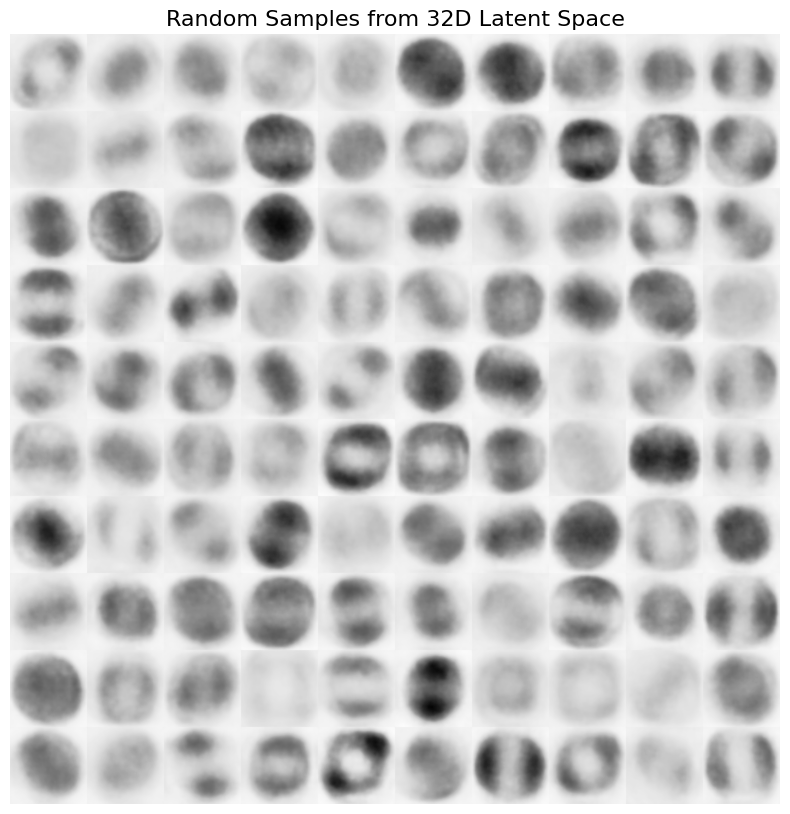

In [149]:
import matplotlib.pyplot as plt


def plot_randomly_generated_images(decoder, latent_dim, n=10, figsize=10):
    """
    Plots a grid of randomly generated digits for any latent dimension.
    """
    # Create a figure to display the images
    figure = np.zeros((IMG_SHAPE[0] * n, IMG_SHAPE[0] * n))

    # Iterate over the grid positions
    for i in range(n):
        for j in range(n):
            # Generate a random latent vector from a normal distribution
            z_sample = np.random.normal(size=(1, latent_dim))

            # Decode the latent vector to generate an image
            x_decoded = decoder.predict(z_sample, verbose=0)

            # Reshape the output to a 28x28 image
            digit = x_decoded[0].reshape(IMG_SHAPE[0], IMG_SHAPE[0])

            # Place the digit into our display figure
            figure[
                i * IMG_SHAPE[0] : (i + 1) * IMG_SHAPE[0], j * IMG_SHAPE[0] : (j + 1) * IMG_SHAPE[0]
            ] = digit

    # Plot the final figure
    plt.figure(figsize=(figsize, figsize))
    plt.imshow(figure, cmap="Greys_r")
    plt.axis("off")
    plt.title(f"Random Samples from {latent_dim}D Latent Space", fontsize=16)
    plt.show()


# --- HOW TO USE ---
# Call the new function with your deeper decoder and its latent dimension
plot_randomly_generated_images(decoder, LATENT_DIM)

### Plot unlabeled latent space

In [150]:
# import numpy as np

# # 1. Run the encoder on the entire test_dataset to get the latent vectors
# print("Generating latent vectors for the custom test set...")
# z_mean, _, _ = encoder.predict(m1_val_dataset)

# # 2. Extract the images from the dataset into a NumPy array for visualization
# print("Extracting images for plotting...")
# test_images = np.concatenate([x for x in m1_val_dataset], axis=0)

# print(f"Processed {len(z_mean)} images.")

In [151]:
# from sklearn.manifold import TSNE

# print("Running t-SNE... (This may take a moment)")
# tsne = TSNE(n_components=2, perplexity=30.0, max_iter=1000, random_state=42)
# tsne_results = tsne.fit_transform(z_mean)

# print("t-SNE complete.")

In [152]:
# from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# def plot_unlabeled_tsne_images(tsne_results, images, zoom=0.5):
#     """Creates a t-SNE plot with original images without needing labels."""

#     fig, ax = plt.subplots(figsize=(12, 12))
#     ax.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.1)

#     # Plot a subset of images to avoid clutter
#     num_images_to_show = 200
#     indices = np.random.choice(range(len(images)), num_images_to_show, replace=False)

#     for i in indices:
#         x, y = tsne_results[i, :]
#         img = images[i]

#         im = OffsetImage(img, cmap='gray', zoom=zoom)
#         ab = AnnotationBbox(im, (x, y), frameon=False, pad=0.0)
#         ax.add_artist(ab)

#     ax.set_title("t-SNE Visualization with Images (Unlabeled)", fontsize=16)
#     ax.set_xlabel("t-SNE Dimension 1")
#     ax.set_ylabel("t-SNE Dimension 2")
#     ax.grid(True)
#     plt.show()

# # Call the function with the extracted test_images
# plot_unlabeled_tsne_images(tsne_results, test_images, zoom=0.2)

### Labeled latent space

#### Get labeled dataset

In [153]:
import os

import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 1. Manually Collect File Paths and Labels ---

print("Manually collecting labeled file paths and labels...")
labeled_file_paths = []
labeled_labels = []
class_names = sorted(
    [
        d
        for d in os.listdir(IMAGES_LABELED_PATH)
        if os.path.isdir(os.path.join(IMAGES_LABELED_PATH, d))
    ]
)
class_map = {name: i for i, name in enumerate(class_names)}
print(class_map)
for class_name in class_names:
    class_dir = os.path.join(IMAGES_LABELED_PATH, class_name)
    for filepath in os.listdir(class_dir):
        labeled_file_paths.append(os.path.join(class_dir, filepath))
        labeled_labels.append(class_map[class_name])

# Convert to NumPy arrays for scikit-learn
labeled_file_paths = np.array(labeled_file_paths)
labeled_labels = np.array(labeled_labels)
print(f"Found {len(labeled_file_paths)} labeled images belonging to {len(class_names)} classes.")


# --- 2. Perform a Stratified Split ---

print("Performing stratified split...")
_, test_files, _, test_labels = train_test_split(
    labeled_file_paths,
    labeled_labels,
    test_size=0.9,
    stratify=labeled_labels,  # This ensures the split is balanced!
    random_state=42,
)

# --- 3. Create tf.data.Dataset Objects ---


def load_and_normalize(path, label):
    """Reads image from path, preprocesses it, and passes label through."""
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=1, expand_animations=False)
    image = tf.image.resize(image, IMG_SHAPE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


# Create the test dataset for final evaluation
labeled_test_ds = tf.data.Dataset.from_tensor_slices((test_files, test_labels))
labeled_test_ds = labeled_test_ds.map(load_and_normalize, num_parallel_calls=tf.data.AUTOTUNE)
labeled_test_ds = labeled_test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Manually collecting labeled file paths and labels...
{'anaphase': 0, 'metaphase': 1, 'prophase': 2, 'telophase': 3}
Found 2713 labeled images belonging to 4 classes.
Performing stratified split...


In [154]:
import numpy as np

# Prepare empty lists to hold the data
test_images_list = []
test_labels_list = []

print("Extracting images and labels from the test dataset...")
# Iterate through the dataset to get all batches
for images, labels in labeled_test_ds:
    test_images_list.append(images.numpy())
    test_labels_list.append(labels.numpy())

# Concatenate all batches into single NumPy arrays
test_images_np = np.concatenate(test_images_list, axis=0)
test_labels_np = np.concatenate(test_labels_list, axis=0)

print(f"Extracted {len(test_images_np)} images and labels.")

Extracting images and labels from the test dataset...
Extracted 2442 images and labels.


2025-10-14 16:28:05.475995: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


#### Get TSNE

In [155]:
from sklearn.manifold import TSNE

print("Generating latent vectors for the test set...")
# We use z_mean for a stable, deterministic representation of the inputs
z_mean, _, _ = encoder.predict(test_images_np)

print("Running t-SNE... (This may take a moment)")
tsne = TSNE(n_components=2, perplexity=30.0, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(z_mean)

print("t-SNE complete.")

Generating latent vectors for the test set...
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Running t-SNE... (This may take a moment)
t-SNE complete.


#### Plot

/tmp/ipykernel_83873/1397942352.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap=plt.cm.get_cmap("jet", num_classes),


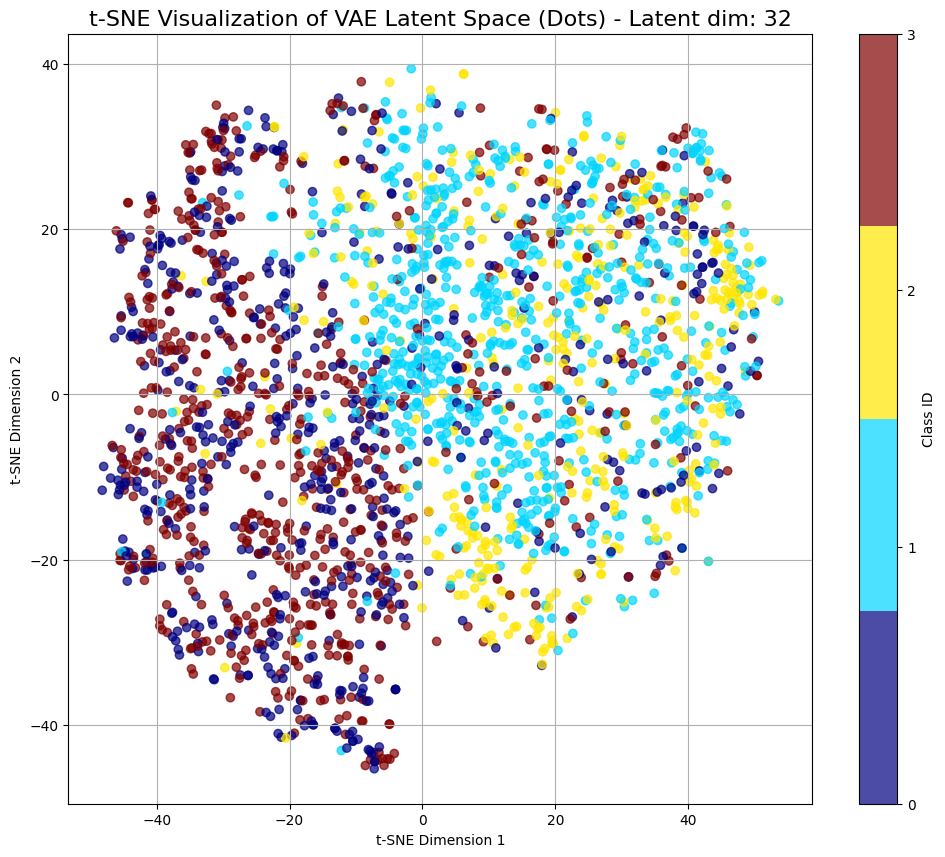

In [156]:
import matplotlib.pyplot as plt


def plot_labeled_tsne_scatter(tsne_results, labels, latent_dim):
    """
    Creates a colored scatter plot of t-SNE results for any number of classes.
    """
    # Determine the number of classes dynamically
    num_classes = len(np.unique(labels))

    plt.figure(figsize=(12, 10))

    scatter = plt.scatter(
        tsne_results[:, 0],
        tsne_results[:, 1],
        c=labels,
        # Use the dynamic number of classes for the colormap
        cmap=plt.cm.get_cmap("jet", num_classes),
        alpha=0.7,
    )

    plt.title(
        f"t-SNE Visualization of VAE Latent Space (Dots) - Latent dim: {latent_dim}", fontsize=16
    )
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")

    # Use the dynamic number of classes for the color bar
    cbar = plt.colorbar(scatter, ticks=range(num_classes))
    cbar.set_label("Class ID")

    plt.grid(True)
    plt.show()


# Call the function with your new data and the latent_dim you used
# Assuming your encoder's latent dimension is 32
plot_labeled_tsne_scatter(tsne_results, test_labels_np, LATENT_DIM)

### Save model

In [157]:
import os

# Create a directory to save the models
model_dir = "../../models/vae/"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Save the encoder and decoder models
encoder_path = os.path.join(
    model_dir, f"encoder_latent{LATENT_DIM}_beta{BETA}_epochs{EPOCHS}.keras"
)
decoder_path = os.path.join(
    model_dir, f"decoder_latent{LATENT_DIM}_beta{BETA}_epochs{EPOCHS}.keras"
)

encoder.save(encoder_path)
decoder.save(decoder_path)

print(f"Encoder and Decoder models saved to the '{model_dir}' directory.")

Encoder and Decoder models saved to the '../../models/vae/' directory.


### TESTS

In [158]:
IMAGE_PATHS = [
    os.path.join(DATASETS_PATH, "cropped", "vae", "test", "prophase", "a_19_29.png"),
    os.path.join(DATASETS_PATH, "cropped", "vae", "test", "metaphase", "a_23_55.png"),
    os.path.join(DATASETS_PATH, "cropped", "vae", "test", "anaphase", "004_00130_51.png"),
    os.path.join(DATASETS_PATH, "cropped", "vae", "test", "telophase", "004_00123_27.png"),
]

In [159]:
custom_objects = {"Sampling": Sampling}
encoder = tf.keras.models.load_model(encoder_path, custom_objects=custom_objects)
decoder = tf.keras.models.load_model(decoder_path)

#### See how image is reconstructed

In [160]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


def plot_reconstruction_comparison(image_paths, encoder, decoder, image_size=IMG_SHAPE):
    """
    Loads 4 images, runs them through a VAE, and plots the originals vs. reconstructions.

    Args:
        image_paths: A list of 4 file paths.
        encoder: The trained VAE encoder model.
        decoder: The trained VAE decoder model.
        image_size: The (height, width) tuple the model expects.
    """
    if len(image_paths) != 4:
        print("Error: Please provide a list of exactly 4 image paths.")
        return

    # --- Helper function to load and process a single image ---
    def _preprocess_image(path):
        image = tf.io.read_file(path)
        # Get the number of channels the encoder expects from its input shape
        channels = 1
        image = tf.image.decode_image(image, channels=channels)
        image = tf.image.resize(image, image_size)
        image = tf.cast(image, tf.float32) / 255.0
        return image

    # --- 1. Load and preprocess all 4 images ---
    original_images = [_preprocess_image(path) for path in image_paths]
    input_batch = tf.stack(original_images)  # Create a single batch of 4 images

    # --- 2. Run the full autoencoding process ---
    # Pass the batch through the encoder to get the latent samples
    _, _, z_samples = encoder.predict(input_batch, verbose=0)
    # Pass the latent samples through the decoder to get the reconstructions
    reconstructed_images = decoder.predict(z_samples, verbose=0)

    # --- 3. Plot the results ---
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    fig.suptitle("Original vs. Reconstructed Images", fontsize=16)

    for i in range(4):
        # Plot Original images on the top row
        ax_orig = axes[0, i]
        ax_orig.imshow(original_images[i].numpy().squeeze(), cmap="gray")
        ax_orig.set_title(f"Original {i + 1}")
        ax_orig.axis("off")

        # Plot Reconstructed images on the bottom row
        ax_recon = axes[1, i]
        ax_recon.imshow(reconstructed_images[i].squeeze(), cmap="gray")
        ax_recon.set_title(f"Reconstructed {i + 1}")
        ax_recon.axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

2025-10-14 16:28:08.063528: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


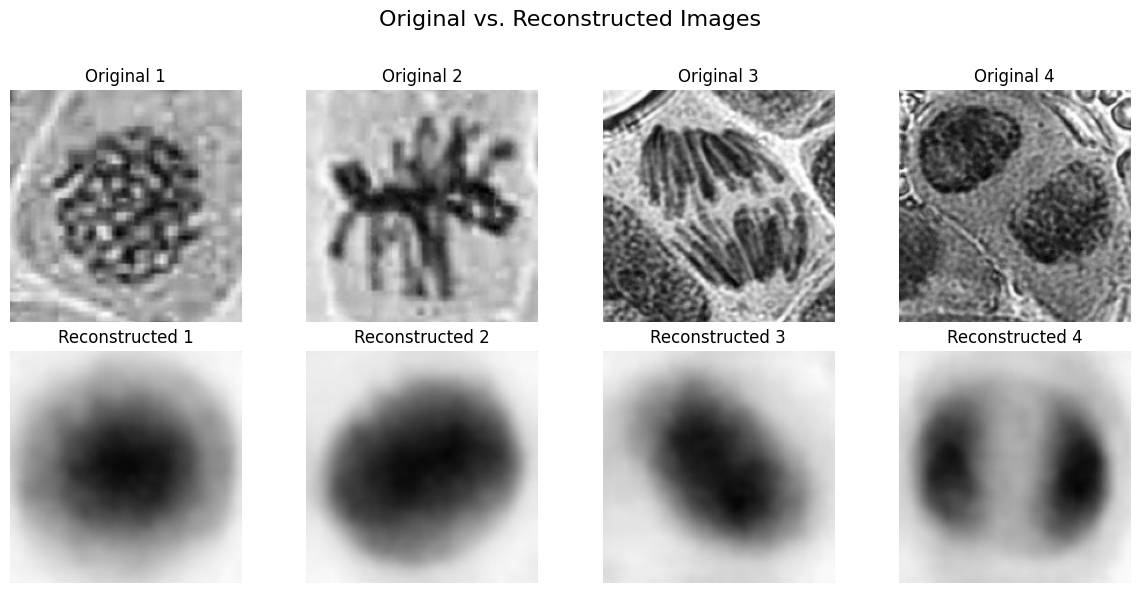

In [161]:
plot_reconstruction_comparison(IMAGE_PATHS, encoder, decoder)

#### Plot TSNE

In [162]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.manifold import TSNE
from tensorflow.keras import layers, models


def plot_tsne_with_key_images(image_paths, encoder, test_dataset, image_shape=IMG_SHAPE):
    """
    Generates a t-SNE plot of a dataset and highlights the positions of specific images.

    Args:
        image_paths: A list of file paths for the images to highlight.
        encoder: The trained VAE encoder model.
        test_dataset: A tf.data.Dataset of (image, label) tuples for the background plot.
    """
    # --- 1. Get Latent Vectors for the Full Test Set (Background) ---
    print("Generating latent vectors for the full test set...")
    all_z_mean_bg, all_labels_bg = [], []
    # Dynamically get class names if they exist on the dataset object
    class_names = getattr(test_dataset, "class_names", None)

    for images, labels in test_dataset:
        z_mean, _, _ = encoder.predict(images, verbose=0)
        all_z_mean_bg.append(z_mean)
        all_labels_bg.append(labels.numpy())
    all_z_mean_bg = np.concatenate(all_z_mean_bg, axis=0)
    all_labels_bg = np.concatenate(all_labels_bg, axis=0)

    # --- 2. Get Latent Vectors for the Key Images ---
    # Helper to preprocess a single image
    def _preprocess_single(path):
        channels = 1
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_image(img_raw, channels=channels)
        img = tf.image.resize(img, image_shape)
        return tf.cast(img, tf.float32) / 255.0

    key_images = tf.stack([_preprocess_single(p) for p in image_paths])
    z_means_keys, _, _ = encoder.predict(key_images, verbose=0)

    # --- 3. Run t-SNE on All Points ---
    print("Running t-SNE...")
    combined_z = np.concatenate([all_z_mean_bg, z_means_keys], axis=0)
    tsne_results = TSNE(
        n_components=2, perplexity=30, max_iter=1000, random_state=42
    ).fit_transform(combined_z)

    tsne_bg = tsne_results[: -len(image_paths)]
    tsne_keys = tsne_results[-len(image_paths) :]

    # --- 4. Plot the t-SNE Map ---
    print("Plotting the latent space map...")
    plt.figure(figsize=(12, 8))

    # Plot the background points with low opacity
    scatter = plt.scatter(
        tsne_bg[:, 0],
        tsne_bg[:, 1],
        c=all_labels_bg,
        cmap="viridis",
        alpha=0.2,
        s=15,
        label="Test Set",
    )

    # Plot the key images on top with a distinct marker
    plt.scatter(tsne_keys[:, 0], tsne_keys[:, 1], c="red", s=200, marker="X", label="Key Images")
    for i, (x, y) in enumerate(tsne_keys):
        plt.text(x + 2, y + 2, f"Image {i + 1}", fontsize=14, color="red", weight="bold")

    plt.title("Latent Space Map with Key Image Locations")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, linestyle="--")

    # Create a clean legend
    if class_names:
        cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
        cbar.set_ticklabels(class_names)
        cbar.set_label("Class ID")
    plt.legend()
    plt.show()

Generating latent vectors for the full test set...
Running t-SNE...
Plotting the latent space map...


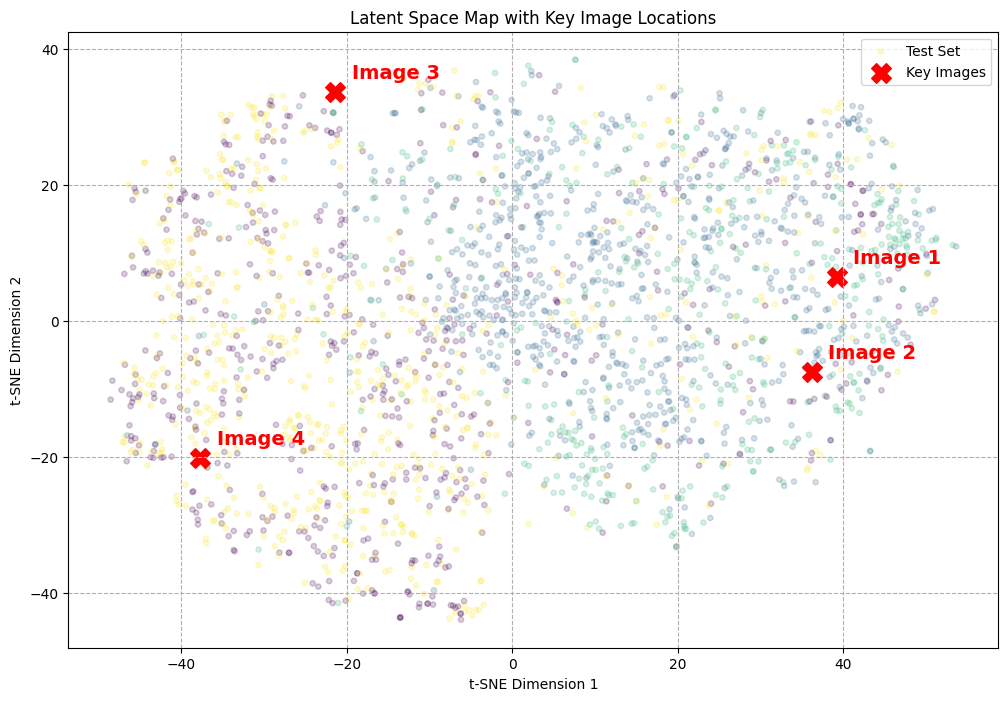

In [163]:
plot_tsne_with_key_images(IMAGE_PATHS, encoder, labeled_test_ds)

#### Progressive reconstruction

In [164]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models


def preprocess_image(image_path, image_size=(200, 200), channels=1):
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_image(img_raw, channels=channels)
    img_resized = tf.image.resize(img, image_size)
    img_normalized = tf.cast(img_resized, tf.float32) / 255.0
    return tf.expand_dims(img_normalized, axis=0)


# --- 2. Load Models and Get Key Latent Vectors ---
def progressive_reconstruction(
    image_paths, input_channels=1, img_shape=IMG_SHAPE, interplotation_steps=10
):
    try:
        # Preprocess all key images and stack them into a single batch
        image_batches = [preprocess_image(path, img_shape, input_channels) for path in image_paths]
        input_batch = tf.concat(image_batches, axis=0)

        # Get the latent vectors (z_mean) for all 4 key images
        z_means, _, _ = encoder.predict(input_batch)
        print("Successfully encoded 4 key images.")

        # --- 3. Perform Linear Interpolation ---
        path_vectors = []
        # Create the path from image 1->2, 2->3, 3->4
        for i in range(len(z_means) - 1):
            start_vec = z_means[i]
            end_vec = z_means[i + 1]
            # Generate intermediate vectors
            for alpha in np.linspace(0, 1, interplotation_steps):
                interpolated_vec = (1 - alpha) * start_vec + alpha * end_vec
                path_vectors.append(interpolated_vec)

        path_vectors = np.array(path_vectors)

        # --- 4. Decode the Path and Plot ---
        print("Decoding interpolated vectors to generate animation...")
        generated_images = decoder.predict(path_vectors)

        # Create the plot
        num_rows = len(z_means) - 1
        fig, axes = plt.subplots(
            nrows=num_rows, ncols=interplotation_steps, figsize=(20, num_rows * 2)
        )
        fig.suptitle("Latent Space Interpolation of Mitosis Progression", fontsize=16)

        for i in range(num_rows):
            for j in range(interplotation_steps):
                img_idx = i * interplotation_steps + j
                ax = axes[i, j]
                ax.imshow(generated_images[img_idx].squeeze(), cmap="gray")
                ax.axis("off")
                # Add labels for start and end points
                if j == 0:
                    ax.set_title(f"Start (Class {i + 1})")
                if j == interplotation_steps - 1:
                    ax.set_title(f"End (Class {i + 2})")

        plt.tight_layout(rect=[0, 0, 1, 0.96])
        plt.show()

    except Exception as e:
        print(
            f"An error occurred. Please check your file paths and ensure your models are compatible.\nError: {e}"
        )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Successfully encoded 4 key images.
Decoding interpolated vectors to generate animation...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


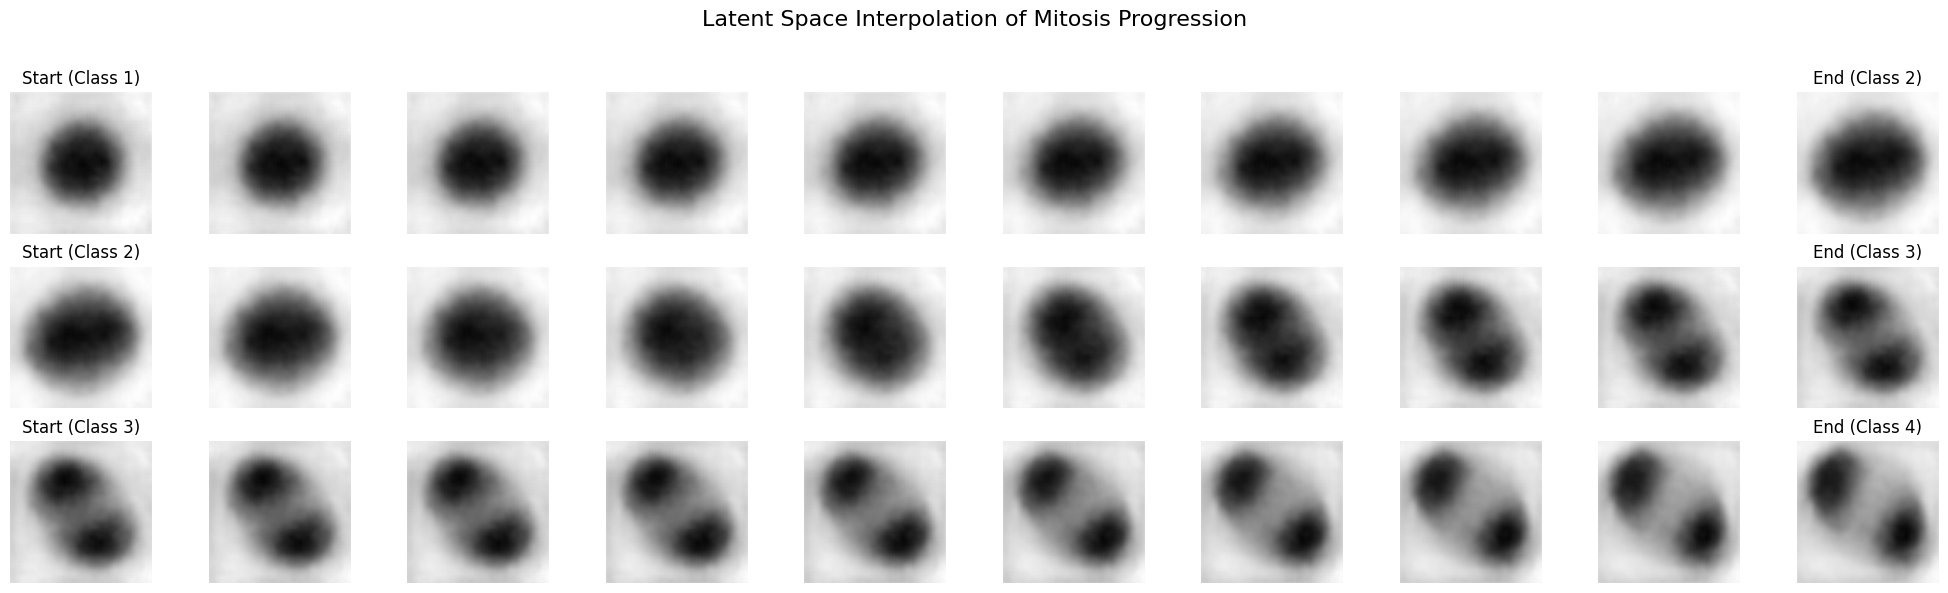

In [165]:
progressive_reconstruction(
    IMAGE_PATHS, input_channels=1, img_shape=IMG_SHAPE, interplotation_steps=10
)

#### Comparisson of latent variances

In [166]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models


# (You must have your custom Sampling layer and preprocess_image function defined as before)
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


def preprocess_image(image_path, image_size=(200, 200), channels=1):
    img_raw = tf.io.read_file(image_path)
    img = tf.image.decode_image(img_raw, channels=channels)
    img_resized = tf.image.resize(img, image_size)
    img_normalized = tf.cast(img_resized, tf.float32) / 255.0
    return tf.expand_dims(img_normalized, axis=0)


def plot_variance_comparison(image_paths, encoder, image_size=(200, 200), channels=1):
    """
    Loads 4 images, gets their latent variances, and plots them in a 2x2 grid.

    Args:
        image_paths: A list of 4 file paths to the images.
        encoder: The trained VAE encoder model.
    """
    if len(image_paths) != 4:
        print("Error: Please provide a list of exactly 4 image paths.")
        return

    # 1. Preprocess all images and combine them into a single batch
    image_batches = [preprocess_image(path, image_size, channels) for path in image_paths]
    input_batch = tf.concat(image_batches, axis=0)

    # 2. Get the latent variables for the entire batch in one go
    z_mean, z_log_var, _ = encoder.predict(input_batch)

    # The variance is the exponential of the log-variance
    variances_batch = np.exp(z_log_var)
    latent_dim = variances_batch.shape[1]

    # 3. Create the 2x2 plot grid
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle("Latent Variance Comparison Across Classes", fontsize=16)

    for i, ax in enumerate(axes.flat):
        # Get the variance vector for the i-th image
        variances = variances_batch[i]
        indices = np.arange(latent_dim)

        # Plot the bar chart
        ax.bar(indices, variances)
        ax.axhline(y=1.0, color="r", linestyle="--", label="Prior Variance (1.0)")
        ax.set_title(f"Variances for Image {i + 1}")
        ax.set_xlabel("Latent Dimension")
        ax.set_ylabel("Variance")
        ax.set_xticks(indices)
        ax.grid(axis="y", linestyle="--", alpha=0.7)
        ax.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


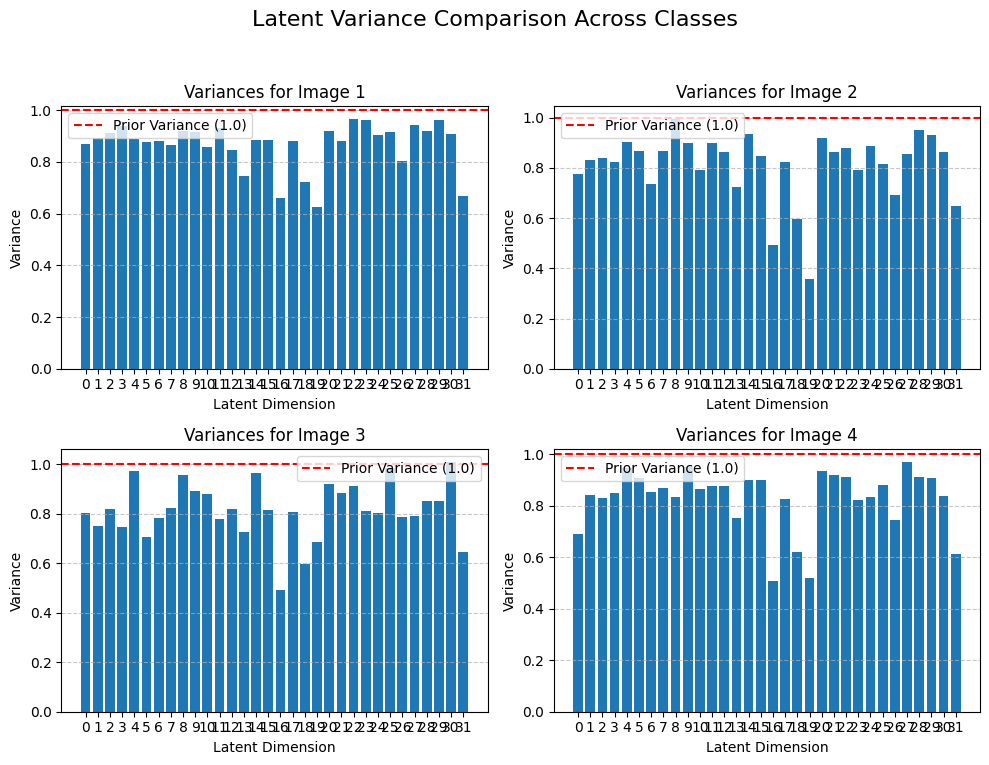

In [167]:
plot_variance_comparison(IMAGE_PATHS, encoder)